In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 셀 2: Scaled Dot-Product Attention
class ScaledDotProductAttention(nn.Module):
    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = F.softmax(scores, dim=-1)
        output = torch.matmul(attn, V)
        return output, attn


In [4]:
# 셀 3: Multi-Head Attention
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention()

    def forward(self, Q, K, V, mask=None):
        bs = Q.size(0)
        Q = self.q_linear(Q).view(bs, -1, self.num_heads, self.d_k).transpose(1,2)
        K = self.k_linear(K).view(bs, -1, self.num_heads, self.d_k).transpose(1,2)
        V = self.v_linear(V).view(bs, -1, self.num_heads, self.d_k).transpose(1,2)

        out, attn = self.attention(Q, K, V, mask)
        out = out.transpose(1,2).contiguous().view(bs, -1, self.num_heads * self.d_k)
        return self.out(out), attn


In [5]:
# 셀 4: Feed Forward Network
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))


In [6]:
# 셀 5: Transformer Block
class TransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads)
        self.ff = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, attn_weights = self.attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))
        return x, attn_weights


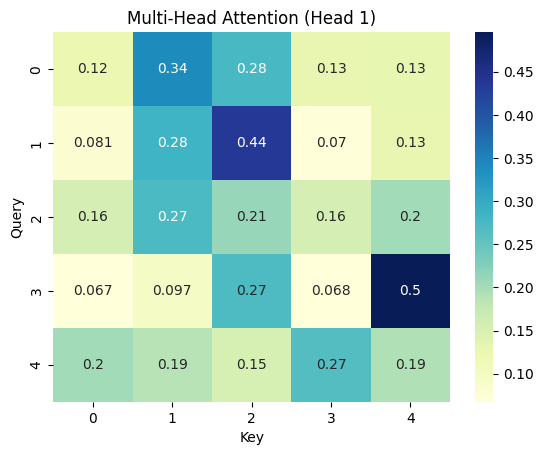

In [7]:
# 셀 6: result, visualization
def generate_toy_data(seq_len=5, d_model=16):
    torch.manual_seed(0)
    return torch.randn(1, seq_len, d_model)

x = generate_toy_data()
transformer = TransformerBlock(d_model=16, num_heads=4, d_ff=64)
output, attn_weights = transformer(x)

# First Head Attention Weight 
sns.heatmap(attn_weights[0][0].detach().numpy(), annot=True, cmap='YlGnBu')
plt.title("Multi-Head Attention (Head 1)")
plt.xlabel("Key")
plt.ylabel("Query")
plt.show()


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]


In [9]:
d_model = 16
seq_len = 10
x = torch.zeros(1, seq_len, d_model)

pe_layer = PositionalEncoding(d_model)
x_pe = pe_layer(x)

print("Position 0:", x_pe[0, 0])
print("Position 1:", x_pe[0, 1])


Position 0: tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.])
Position 1: tensor([8.4147e-01, 5.4030e-01, 3.1098e-01, 9.5042e-01, 9.9833e-02, 9.9500e-01,
        3.1618e-02, 9.9950e-01, 9.9998e-03, 9.9995e-01, 3.1623e-03, 9.9999e-01,
        1.0000e-03, 1.0000e+00, 3.1623e-04, 1.0000e+00])


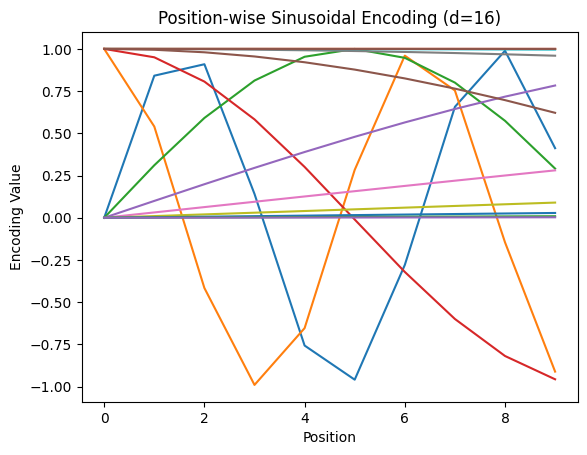

In [10]:
import matplotlib.pyplot as plt

plt.plot(x_pe[0].detach().numpy())
plt.title("Position-wise Sinusoidal Encoding (d=16)")
plt.xlabel("Position")
plt.ylabel("Encoding Value")
plt.show()


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10016\2411359933.py:36: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE BYEON}) missing from current font.
  plt.tight_layout()
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_10016\2411359933.py:36: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from current font.
  plt.tight_layout()


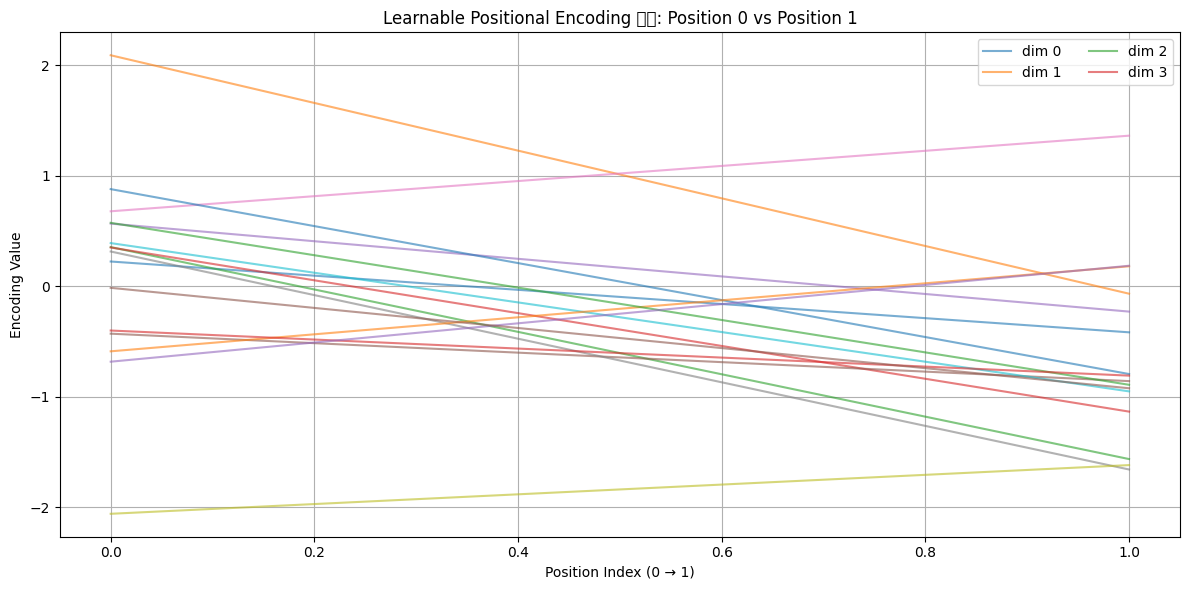

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Learnable Positional Encoding
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        return x + self.pos_embedding[:, :x.size(1), :]

# 입력 텐서 생성
d_model = 16
seq_len = 10
x = torch.zeros(1, seq_len, d_model)  # 배치 크기 1

# 레이어 적용
learnable_pe = LearnablePositionalEncoding(d_model=d_model, max_len=seq_len)
x_lpe = learnable_pe(x)

# 위치 0과 위치 1의 벡터 추출
pos_0 = x_lpe[0, 0].detach().numpy()
pos_1 = x_lpe[0, 1].detach().numpy()

# 시각화
plt.figure(figsize=(12, 6))
for i in range(d_model):
    plt.plot([pos_0[i], pos_1[i]], label=f'dim {i}' if i < 4 else "", alpha=0.6)
plt.title("Learnable Positional Encoding 변화: Position 0 vs Position 1")
plt.xlabel("Position Index (0 → 1)")
plt.ylabel("Encoding Value")
plt.grid(True)
plt.legend(loc='upper right', ncol=2)
plt.tight_layout()
plt.show()


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Learnable Positional Encoding
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, d_model))

    def forward(self, x):
        return x + self.pos_embedding[:, :x.size(1), :]

# Sinusoidal Positional Encoding
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]
    

In [16]:
class SimpleSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.query = nn.Linear(d_model, d_model)
        self.key = nn.Linear(d_model, d_model)
        self.value = nn.Linear(d_model, d_model)
        self.scale = d_model ** 0.5

    def forward(self, x):
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)
        attn_weights = F.softmax(Q @ K.transpose(-2, -1) / self.scale, dim=-1)
        output = attn_weights @ V
        return output, attn_weights

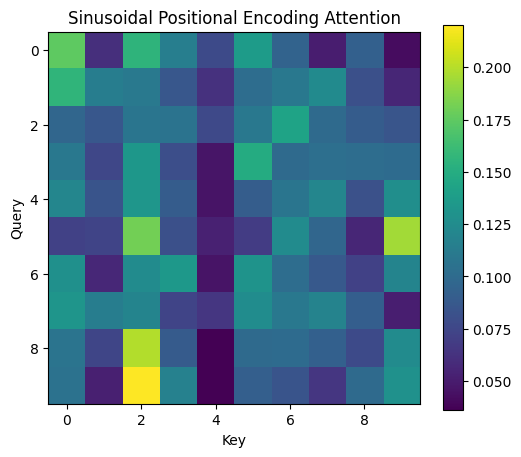

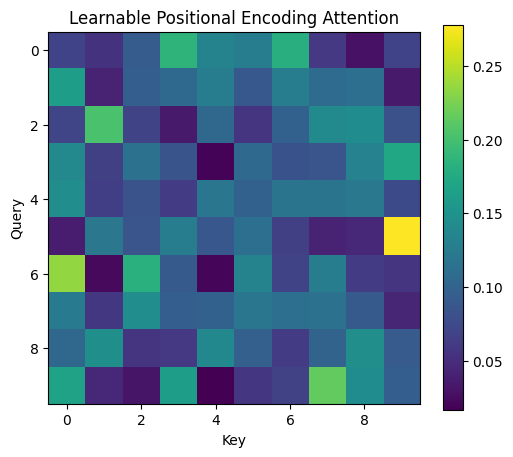

In [17]:
# 설정값
seq_len = 10
d_model = 16
x = torch.randn(1, seq_len, d_model)

# Positional Encoding 적용
spe = SinusoidalPE(d_model, seq_len)
lpe = LearnablePositionalEncoding(d_model, seq_len)
x_spe = spe(x)
x_lpe = lpe(x)

# Attention 계산
attn_layer = SimpleSelfAttention(d_model)
_, attn_spe = attn_layer(x_spe)
_, attn_lpe = attn_layer(x_lpe)

# 시각화
def plot_attention(attn, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(attn[0].detach().numpy(), cmap='viridis')
    plt.title(title)
    plt.xlabel("Key")
    plt.ylabel("Query")
    plt.colorbar()
    plt.show()

plot_attention(attn_spe, "Sinusoidal Positional Encoding Attention")
plot_attention(attn_lpe, "Learnable Positional Encoding Attention")
